In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmideepikapeyala/upi-transactions/UPI Transactions Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import os

# Automatically find the CSV/Excel file
file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv') or filename.endswith('.xlsx'):
            file_path = os.path.join(dirname, filename)
            print("Found:", file_path)

# Load it
if file_path.endswith('.csv'):
    df = pd.read_csv(file_path)
else:
    df = pd.read_excel(file_path)

print("\nOriginal rows:", len(df))

# Clean: remove duplicates
df = df.drop_duplicates(subset=['Transaction_ID'])
print("After dedup:", len(df))

# Clean: fill missing payment app if any
if 'Payment_App' in df.columns:
    df['Payment_App'] = df['Payment_App'].fillna('Unknown')

print("\nColumns:", df.columns.tolist())
df.head()

Found: /kaggle/input/datasets/lakshmideepikapeyala/upi-transactions/UPI Transactions Dataset.csv

Original rows: 12000
After dedup: 12000

Columns: ['Transaction_ID', 'Date', 'Time', 'Amount_INR', 'User_ID', 'Sender_UPI_ID', 'Receiver_UPI_ID', 'Payment_App', 'Sender_Bank', 'Receiver_Bank', 'Merchant_Category', 'Transaction_Type', 'Payment_Status', 'City', 'Device_Type', 'User_Age_Group']


,Transaction_ID,Date,Time,Amount_INR,User_ID,Sender_UPI_ID,Receiver_UPI_ID,Payment_App,Sender_Bank,Receiver_Bank,Merchant_Category,Transaction_Type,Payment_Status,City,Device_Type,User_Age_Group
0,TXN0000001,2025-07-01,02:22:37,2376.42,USR03892,user855@google,merchant1070@oksbi,Google Pay,Axis Bank,ICICI Bank,Entertainment,P2M,Success,Mumbai,Android,18-25
1,TXN0000002,2025-07-01,07:21:10,1579.97,USR01345,user126@paytm,merchant732@okaxis,Paytm,Punjab National Bank,HDFC Bank,Utilities & Bill Payments,P2M,Success,Varanasi,Android,36-45
2,TXN0000003,2025-07-01,08:16:25,746.92,USR03086,user2164@google,merchant139@okicici,Google Pay,ICICI Bank,Axis Bank,Healthcare,P2M,Success,Hyderabad,Android,26-35
3,TXN0000004,2025-07-01,08:17:37,3535.16,USR01725,user2084@phonep,merchant152@ybl,PhonePe,Bank of Baroda,Union Bank of India,Shopping,P2M,Success,Guwahati,iOS,18-25
4,TXN0000005,2025-07-01,08:58:25,5183.71,USR02085,user1574@google,merchant967@okaxis,Google Pay,Bank of Baroda,Union Bank of India,Shopping,P2M,Success,Ahmedabad,Android,36-45


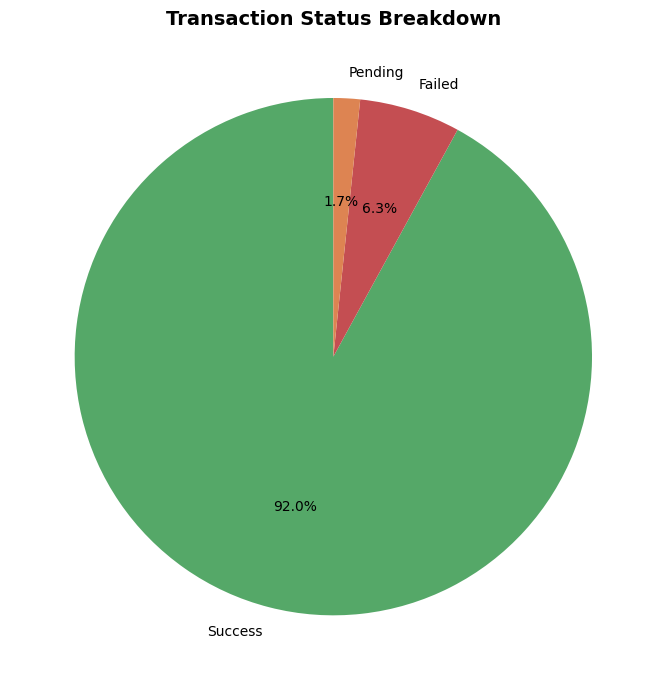

In [3]:
import matplotlib.pyplot as plt

status_counts = df['Payment_Status'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#55A868', '#C44E52', '#DD8452']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Transaction Status Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('status_breakdown.png', dpi=150)
plt.show()

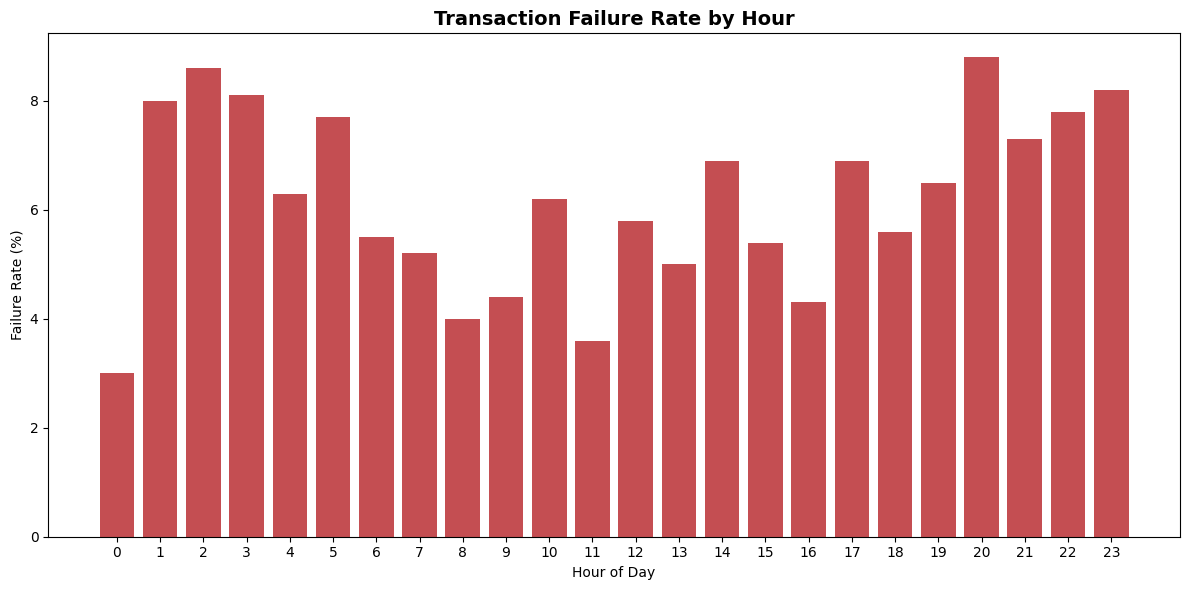

In [4]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

hourly = df.groupby('Time').agg(
    total=('Transaction_ID', 'count'),
    failed=('Payment_Status', lambda x: (x == 'Failed').sum())
)
hourly['failure_rate'] = (hourly['failed'] / hourly['total'] * 100).round(1)

plt.figure(figsize=(12, 6))
plt.bar(hourly.index, hourly['failure_rate'], color='#C44E52')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Rate (%)')
plt.title('Transaction Failure Rate by Hour', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('failure_by_hour.png', dpi=150)
plt.show()

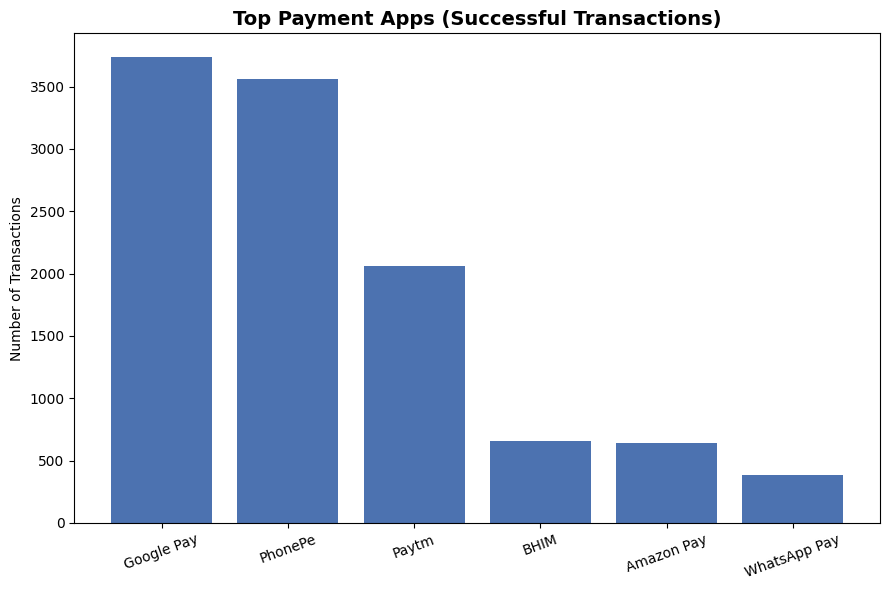

In [5]:
app_counts = df[df['Payment_Status']=='Success']['Payment_App'].value_counts()

plt.figure(figsize=(9, 6))
plt.bar(app_counts.index, app_counts.values, color='#4C72B0')
plt.ylabel('Number of Transactions')
plt.title('Top Payment Apps (Successful Transactions)', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('top_apps.png', dpi=150)
plt.show()

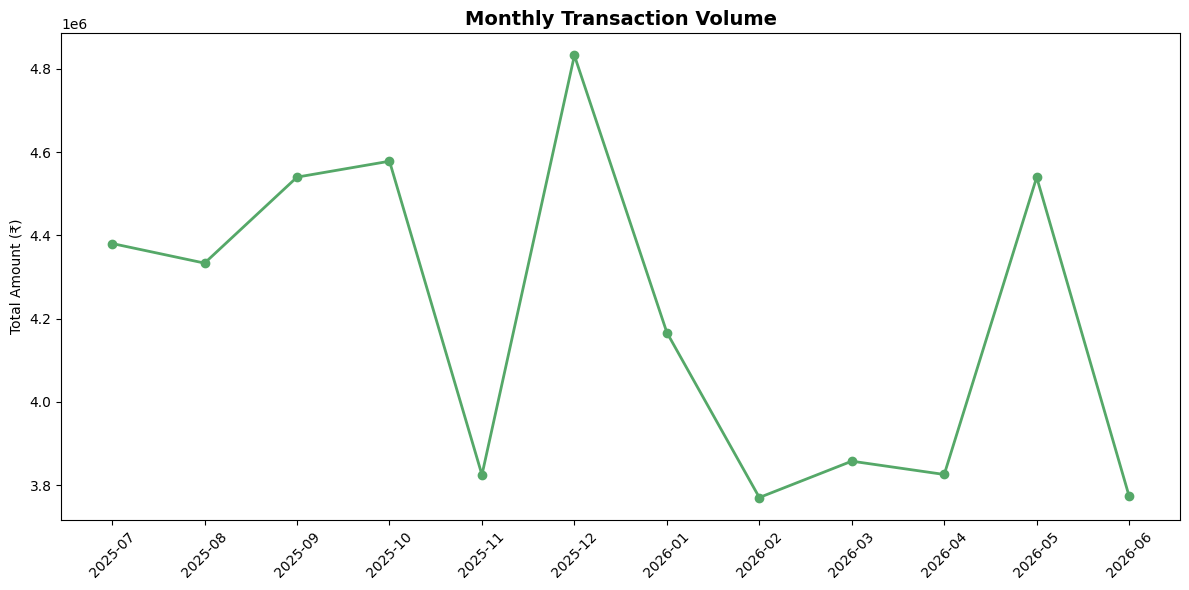

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.to_period('M').astype(str)

monthly = df[df['Payment_Status']=='Success'].groupby('month')['Amount_INR'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly.values, marker='o', color='#55A868', linewidth=2)
plt.xticks(rotation=45)
plt.ylabel('Total Amount (₹)')
plt.title('Monthly Transaction Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

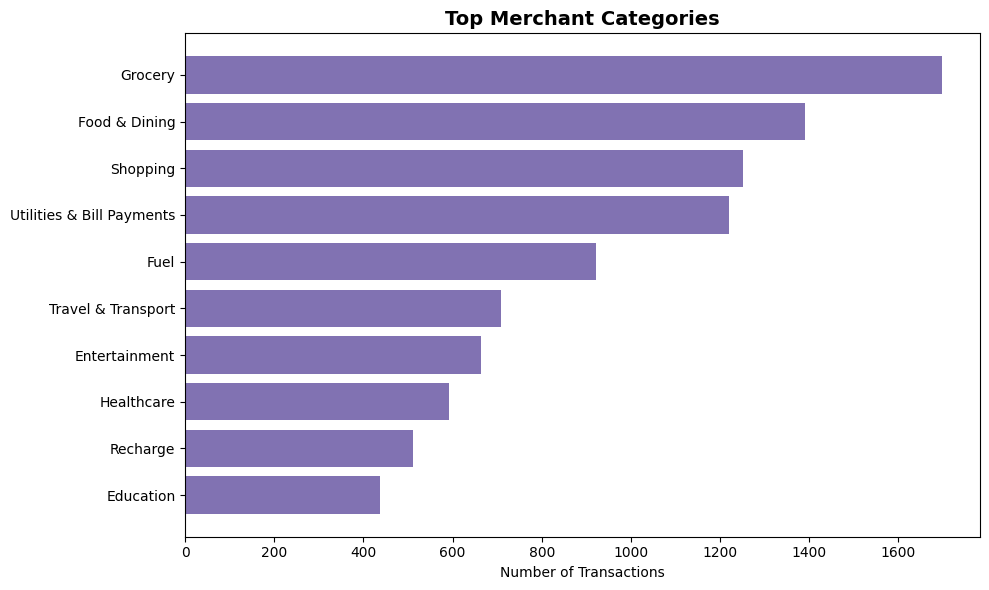

In [7]:
merchant_data = df[(df['Payment_Status']=='Success') & (df['Transaction_Type']=='P2M')]
category_counts = merchant_data['Merchant_Category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(category_counts.index[::-1], category_counts.values[::-1], color='#8172B2')
plt.xlabel('Number of Transactions')
plt.title('Top Merchant Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('merchant_categories.png', dpi=150)
plt.show()